# Notebook 1 - Data Understanding

## The problem we are solving

An online shopping company loses customers every month. When a customer stops
buying and never comes back, we say that customer has **churned**.

Winning a brand new customer costs a company much more money than keeping an
existing one. So the company wants to know, **before** a customer leaves:

> "Which of our customers are about to leave, and why?"

If we can answer that, the company can call those customers, fix their
complaints, or send them an offer while there is still time.

## What this notebook does

This is the **first** step of the project. We do **not** build any model here.
We only get to know our data, the same way a doctor examines a patient before
giving any medicine.

In this notebook we:

1. Load the raw Excel file.
2. Write down what every column means.
3. Check the data quality (blank cells, duplicate rows).
4. Look at how many customers actually churned.
5. Save a clean copy of the table for the next notebooks.

| | |
|---|---|
| **Input** | `data/raw/E_Commerce_Dataset.xlsx` |
| **Output** | `data/clean/step1_customers.csv`, `data/clean/feature_dictionary.csv`, 2 charts in `figures/` |
| **Why it is needed** | Every later notebook reads the file this notebook saves. Without it the pipeline cannot start. |

## Step 0 - Tools and file locations

We only need three libraries in this notebook:

- `os` — a built-in Python library used here to create folders.
- `pandas` — lets us hold a table in memory and is the main tool of the project.
- `matplotlib` — draws the charts.

The `..` in the file paths means **"go up one folder"**. Our notebook sits
inside `notebooks/`, and the data sits inside `data/`, so we go up one level
first and then come back down into `data/`.

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

RAW_FILE = "../data/raw/E_Commerce_Dataset.xlsx"
CLEAN_FOLDER = "../data/clean"
FIGURE_FOLDER = "../figures"

os.makedirs(CLEAN_FOLDER, exist_ok=True)
os.makedirs(FIGURE_FOLDER, exist_ok=True)

print("This notebook is running inside:", os.getcwd())
print("It will read the file        :", RAW_FILE)
print("It will save tables into     :", CLEAN_FOLDER)
print("It will save charts into     :", FIGURE_FOLDER)

This notebook is running inside: C:\Users\ishan\OneDrive\Documents\Work\3 Year 2 Semester\IT41033 - Nature Inspired Algorithms\Mini Project\ecommerce-customer-churn-prediction\notebooks
It will read the file        : ../data/raw/E_Commerce_Dataset.xlsx
It will save tables into     : ../data/clean
It will save charts into     : ../figures


## Step 1 - Load the raw data

The Excel workbook contains a sheet named `E Comm`. One **row** is one
customer, and one **column** is one piece of information about that customer.

`pd.read_excel` reads that sheet and gives us a table (pandas calls it a
`DataFrame`). We store it in a variable called `customers`.

In [3]:
customers = pd.read_excel(RAW_FILE, sheet_name="E Comm")

number_of_rows = customers.shape[0]
number_of_columns = customers.shape[1]

print("Number of customers (rows):", number_of_rows)
print("Number of details (columns):", number_of_columns)
print()
print("The columns are:")
for column_name in customers.columns:
    print(" -", column_name)

customers.head()

Number of customers (rows): 5630
Number of details (columns): 20

The columns are:
 - CustomerID
 - Churn
 - Tenure
 - PreferredLoginDevice
 - CityTier
 - WarehouseToHome
 - PreferredPaymentMode
 - Gender
 - HourSpendOnApp
 - NumberOfDeviceRegistered
 - PreferedOrderCat
 - SatisfactionScore
 - MaritalStatus
 - NumberOfAddress
 - Complain
 - OrderAmountHikeFromlastYear
 - CouponUsed
 - OrderCount
 - DaySinceLastOrder
 - CashbackAmount


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## Step 2 - What does each column mean?

A data mining project must start by understanding the meaning of every column.
If we do not know what a column means, we cannot judge whether the model's
answer makes sense.

We write the meanings into a normal Python **dictionary**. A dictionary stores
pairs: on the left the column name (the *key*), on the right the explanation
(the *value*). Then we turn that dictionary into a small table and save it, so
the whole group can read it before the presentation.

In [3]:
column_meanings = {
    "CustomerID": "Unique number of the customer. Only an ID, never used to predict.",
    "Churn": "TARGET. 1 = the customer left, 0 = the customer stayed.",
    "Tenure": "How many months the person has been a customer.",
    "PreferredLoginDevice": "Device used to log in (Computer / Mobile Phone / Phone).",
    "CityTier": "City size group: 1 = big city, 2 = medium, 3 = small.",
    "WarehouseToHome": "Distance in km from the warehouse to the customer's home.",
    "PreferredPaymentMode": "Favourite way of paying (Debit Card, Credit Card, UPI, ...).",
    "Gender": "Male or Female.",
    "HourSpendOnApp": "Average hours spent on the app or website.",
    "NumberOfDeviceRegistered": "How many devices the account is linked to.",
    "PreferedOrderCat": "Product category ordered most often.",
    "SatisfactionScore": "Satisfaction rating given by the customer, from 1 to 5.",
    "MaritalStatus": "Single, Married or Divorced.",
    "NumberOfAddress": "How many delivery addresses the customer saved.",
    "Complain": "1 = the customer complained last month, 0 = no complaint.",
    "OrderAmountHikeFromlastYear": "Percentage increase in spending compared to last year.",
    "CouponUsed": "How many discount coupons were used last month.",
    "OrderCount": "How many orders were placed last month.",
    "DaySinceLastOrder": "How many days ago the last order was placed.",
    "CashbackAmount": "Average cashback money received by the customer.",
}

dictionary_rows = []
for column_name in customers.columns:
    data_type = str(customers[column_name].dtype)
    meaning = column_meanings[column_name]
    dictionary_rows.append([column_name, data_type, meaning])

feature_dictionary = pd.DataFrame(
    dictionary_rows, columns=["Column", "DataType", "Meaning"]
)
feature_dictionary.to_csv(CLEAN_FOLDER + "/feature_dictionary.csv", index=False)

print("Saved the feature dictionary. It has", len(feature_dictionary), "rows.")
feature_dictionary

Saved the feature dictionary. It has 20 rows.


,Column,DataType,Meaning
0,CustomerID,int64,"Unique number of the customer. Only an ID, nev..."
1,Churn,int64,"TARGET. 1 = the customer left, 0 = the custome..."
2,Tenure,float64,How many months the person has been a customer.
3,PreferredLoginDevice,str,Device used to log in (Computer / Mobile Phone...
4,CityTier,int64,"City size group: 1 = big city, 2 = medium, 3 =..."
5,WarehouseToHome,float64,Distance in km from the warehouse to the custo...
6,PreferredPaymentMode,str,"Favourite way of paying (Debit Card, Credit Ca..."
7,Gender,str,Male or Female.
8,HourSpendOnApp,float64,Average hours spent on the app or website.
9,NumberOfDeviceRegistered,int64,How many devices the account is linked to.


## Step 3 - Data quality check

Before trusting any data we ask four questions:

1. **What type is each column?** Numbers and text must be handled differently.
2. **Are there blank cells?** A blank cell is called a *missing value*. Most
   models refuse to work if even one cell is blank.
3. **Are there duplicate rows?** The same customer counted twice would make the
   model believe that person is more important than the others.
4. **What do the numbers look like?** Summary statistics (min, max, mean, median)
   show scale, skew, and suspicious values before any modelling.

In [4]:
print("=== 1. Data type of every column ===")
print(customers.dtypes)

print()
print("=== 2. Columns that contain blank cells ===")
missing_counts = customers.isna().sum()
for column_name in customers.columns:
    number_missing = missing_counts[column_name]
    if number_missing > 0:
        percent_missing = number_missing / number_of_rows * 100
        print(column_name, "->", number_missing, "blanks =", round(percent_missing, 1), "%")

print()
print("=== 3. Duplicate check ===")
print("Total rows                    :", number_of_rows)
print("Different CustomerID values   :", customers["CustomerID"].nunique())
print("Rows that repeat completely   :", customers.duplicated().sum())

=== 1. Data type of every column ===
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHikeFromlastYear    float64
CouponUsed                     float64
OrderCount                     float64
DaySinceLastOrder              float64
CashbackAmount                 float64
dtype: object

=== 2. Columns that contain blank cells ===
Tenure -> 264 blanks = 4.7 %
WarehouseToHome -> 251 blanks = 4.5 %
HourSpendOnApp -> 255 blanks = 4.5 %
OrderAmountHikeFroml

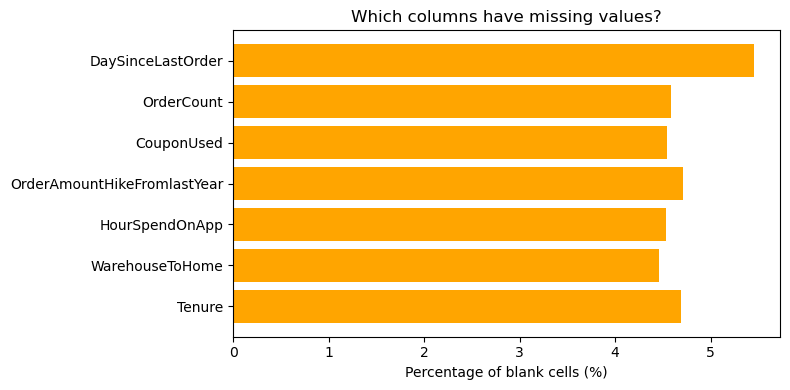

Number of columns that have at least one blank cell: 7


In [5]:
columns_with_blanks = []
percent_of_blanks = []

for column_name in customers.columns:
    percent = customers[column_name].isna().mean() * 100
    if percent > 0:
        columns_with_blanks.append(column_name)
        percent_of_blanks.append(percent)

plt.figure(figsize=(8, 4))
plt.barh(columns_with_blanks, percent_of_blanks, color="orange")
plt.xlabel("Percentage of blank cells (%)")
plt.title("Which columns have missing values?")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/1_missing_values.png", dpi=150)
plt.show()

print("Number of columns that have at least one blank cell:", len(columns_with_blanks))

### What this chart tells us

Seven columns have blank cells, each one missing roughly **4-5%** of its
values. All seven describe customer *behaviour* (tenure, hours on the app,
orders, coupons, cashback, delivery distance), not identity.

**Why this matters.** If we deleted every row that has at least one blank
cell we would throw away about a quarter of our customers, and we would very
likely delete the unusual customers — exactly the ones most likely to churn.
That would bias the whole project.

**Our decision:** keep every customer and *fill* the blanks in notebook 3
using the median of the column. We record the decision now and act on it later,
because cleaning belongs to the preprocessing stage.

**Duplicates:** every `CustomerID` appears once and no row repeats completely,
so we have nothing to delete here. That is a good sign about data collection.

## Step 3b — Summary statistics (`describe`)

`describe()` summarises every **numeric** column: count, mean, std, min,
quartiles, and max. We use it to spot:

- very different scales (e.g. CashbackAmount vs SatisfactionScore)
- possible data-entry errors (impossible min/max)
- heavy skew (mean far from the middle quartile)

Categorical columns are summarised with value counts in notebook 2.

In [4]:
# Numeric summary — exclude CustomerID (identifier) and keep Churn for context
numeric_summary = customers.drop(columns=["CustomerID"]).describe().T
numeric_summary = numeric_summary.round(2)
print("Summary statistics for numeric columns:")
print(numeric_summary)

# Save for the report
numeric_summary.to_csv(CLEAN_FOLDER + "/step1_numeric_describe.csv")
print()
print("Saved:", CLEAN_FOLDER + "/step1_numeric_describe.csv")
numeric_summary

Summary statistics for numeric columns:
                              count    mean    std   min     25%     50%  \
Churn                        5630.0    0.17   0.37   0.0    0.00    0.00   
Tenure                       5366.0   10.19   8.56   0.0    2.00    9.00   
CityTier                     5630.0    1.65   0.92   1.0    1.00    1.00   
WarehouseToHome              5379.0   15.64   8.53   5.0    9.00   14.00   
HourSpendOnApp               5375.0    2.93   0.72   0.0    2.00    3.00   
NumberOfDeviceRegistered     5630.0    3.69   1.02   1.0    3.00    4.00   
SatisfactionScore            5630.0    3.07   1.38   1.0    2.00    3.00   
NumberOfAddress              5630.0    4.21   2.58   1.0    2.00    3.00   
Complain                     5630.0    0.28   0.45   0.0    0.00    0.00   
OrderAmountHikeFromlastYear  5365.0   15.71   3.68  11.0   13.00   15.00   
CouponUsed                   5374.0    1.75   1.89   0.0    1.00    1.00   
OrderCount                   5372.0    3.01   2.

,count,mean,std,min,25%,50%,75%,max
Churn,5630.0,0.17,0.37,0.0,0.00,0.00,0.00,1.00
Tenure,5366.0,10.19,8.56,0.0,2.00,9.00,16.00,61.00
CityTier,5630.0,1.65,0.92,1.0,1.00,1.00,3.00,3.00
WarehouseToHome,5379.0,15.64,8.53,5.0,9.00,14.00,20.00,127.00
HourSpendOnApp,5375.0,2.93,0.72,0.0,2.00,3.00,3.00,5.00
NumberOfDeviceRegistered,5630.0,3.69,1.02,1.0,3.00,4.00,4.00,6.00
SatisfactionScore,5630.0,3.07,1.38,1.0,2.00,3.00,4.00,5.00
NumberOfAddress,5630.0,4.21,2.58,1.0,2.00,3.00,6.00,22.00
Complain,5630.0,0.28,0.45,0.0,0.00,0.00,1.00,1.00
OrderAmountHikeFromlastYear,5365.0,15.71,3.68,11.0,13.00,15.00,18.00,26.00


## Step 4 - How many customers actually churned?

`Churn` is our **target**: the column we want to predict. It holds only two
values, so this is a **binary classification** problem.

Counting the two groups is the most important number in the whole project,
because it decides which score we use to judge our models.

Customers who stayed (Churn = 0): 4682
Customers who left   (Churn = 1): 948
Churn rate: 16.84 %


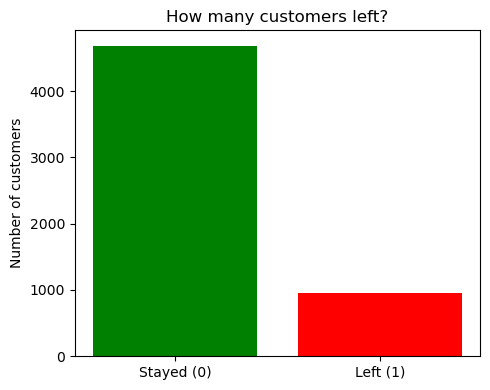

In [6]:
number_retained = (customers["Churn"] == 0).sum()
number_churned = (customers["Churn"] == 1).sum()
churn_rate = number_churned / number_of_rows * 100

print("Customers who stayed (Churn = 0):", number_retained)
print("Customers who left   (Churn = 1):", number_churned)
print("Churn rate:", round(churn_rate, 2), "%")

plt.figure(figsize=(5, 4))
plt.bar(
    ["Stayed (0)", "Left (1)"],
    [number_retained, number_churned],
    color=["green", "red"],
)
plt.ylabel("Number of customers")
plt.title("How many customers left?")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/1_churn_balance.png", dpi=150)
plt.show()

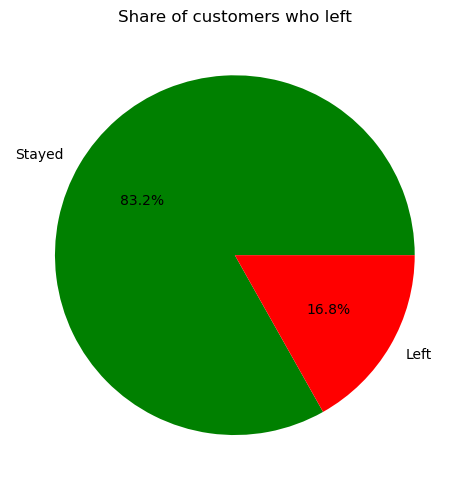

In [7]:
plt.figure(figsize=(5, 5))
plt.pie(
    [number_retained, number_churned],
    labels=["Stayed", "Left"],
    colors=["green", "red"],
    autopct="%1.1f%%",
)
plt.title("Share of customers who left")
plt.tight_layout()
plt.savefig(FIGURE_FOLDER + "/1_churn_share.png", dpi=150)
plt.show()

### The most important finding of this notebook

Only about **17 out of every 100 customers churned**. The two groups are very
unequal, and we call this an **imbalanced dataset**.

Here is why that single number changes the whole project.

Imagine a lazy model that never thinks and simply answers *"this customer will
stay"* for everybody. It would be correct for the 83 customers who stayed and
wrong for the 17 who left. Its **accuracy would be 83%** — which sounds
excellent — yet it would catch **zero** churners and be completely useless to
the company.

So accuracy is a misleading score here. We will judge our models mainly by:

- **Recall** — out of all the customers who really left, how many did we catch?
- **F1-score** — a fair balance between recall and precision.
- **PR-AUC** — how good the model is at ranking risky customers first.

We still report accuracy, but only as a secondary check.

**Business reading of the two error types:**

| Mistake | What it means | What it costs |
|---|---|---|
| **False Negative** — we say "will stay", the customer leaves | We never contacted them | We lose the customer and all their future purchases |
| **False Positive** — we say "will leave", the customer stays | We sent an unnecessary offer | We waste a small discount |

A false negative is far more expensive than a false positive. That is the
business reason we optimise **recall**.

## Step 5 - Save the table for the next notebook

We never change the original Excel file. Instead we save our own copy as a CSV
file inside `data/clean/`.

Two reasons:

1. The raw file stays untouched, so we can always start again from zero.
2. CSV loads much faster than Excel, and notebooks 2 and 3 read it many times.

In [8]:
output_file = CLEAN_FOLDER + "/step1_customers.csv"
customers.to_csv(output_file, index=False)

print("Saved:", output_file)
print()
print("Summary of notebook 1")
print("---------------------")
print("Customers            :", number_of_rows)
print("Columns              :", number_of_columns)
print("Churn rate           :", round(churn_rate, 2), "%")
print("Columns with blanks  :", len(columns_with_blanks))
print("Duplicate rows       :", customers.duplicated().sum())

Saved: ../data/clean/step1_customers.csv

Summary of notebook 1
---------------------
Customers            : 5630
Columns              : 20
Churn rate           : 16.84 %
Columns with blanks  : 7
Duplicate rows       : 0


## Conclusion of notebook 1

**What we learned**

1. We have 5,630 customers described by 20 columns.
2. Seven behaviour columns are about 4-5% blank; we will fill them with the
   median instead of deleting customers.
3. There are no duplicate customers, so the data was collected cleanly.
4. Only ~17% of customers churned, so the data is imbalanced and **accuracy is
   the wrong score to trust**. We will judge models by recall, F1 and PR-AUC.
5. `describe()` shows different numeric scales and some skew — median fill and
   RobustScaler in notebook 3 are appropriate.
6. Three text columns contain the *same thing written two ways* (for example
   `Phone` and `Mobile Phone`). Notebook 2 investigates this and notebook 3
   fixes it.

**Files created**

- `data/clean/step1_customers.csv` — the table every later notebook reads
- `data/clean/feature_dictionary.csv` — the meaning of every column
- `data/clean/step1_numeric_describe.csv` — numeric summary statistics
- `figures/1_missing_values.png`, `figures/1_churn_balance.png`, `figures/1_churn_share.png`
